In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [2]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [3]:
save_path = os.path.expanduser('~/paper_cifar_models/cnn/pca-init-cifar/')
print('save_path:', save_path)
if not os.path.exists(save_path):
    os.makedirs(save_path)

save_path: /home/david/paper_cifar_models/cnn/pca-init-cifar/


In [4]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
import torch.nn as nn
from sklearn.decomposition import PCA

def _find_last_linear_in_encoder(model: nn.Module) -> nn.Linear:
    last = None
    for m in model.encoder.modules():
        if isinstance(m, nn.Linear):
            last = m
    assert isinstance(last, nn.Linear), "No Linear layer found at end of encoder."
    return last

@torch.no_grad()
def initialize_with_feature_pca(model, dataloader, device, n_components=128, max_batches=None, random_state=0):
    """
    Fit PCA on the inputs to the encoder's last Linear layer and
    initialize encoder/decoder Linear layers accordingly.
    """
    model.eval()
    last_linear = _find_last_linear_in_encoder(model)

    feats = []
    def hook(module, inputs, output):
        x = inputs[0].detach()           # input to last Linear, shape [B, 1024]
        feats.append(x.reshape(x.size(0), -1).cpu())

    handle = last_linear.register_forward_hook(hook)

    seen = 0
    for b_idx, (x, _) in enumerate(dataloader):
        x = x.to(device, non_blocking=True)
        _ = model.encoder(x)             # run only the encoder to trigger the hook
        seen += x.size(0)
        if max_batches is not None and (b_idx + 1) >= max_batches:
            break

    handle.remove()
    features = torch.cat(feats, dim=0).numpy().astype('float32')

    # PCA on encoder features
    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=random_state)
    pca.fit(features)                    # sklearn centers internally; mean_ and components_ are set

    W_enc = torch.from_numpy(pca.components_.astype('float32')).to(device=device, dtype=last_linear.weight.dtype)
    mu = torch.from_numpy(pca.mean_.astype('float32')).to(device=device, dtype=last_linear.weight.dtype)
    b_enc = -W_enc @ mu                  # implement centering: y = W(x - mu)

    # Set encoder last Linear
    assert W_enc.shape == last_linear.weight.shape, f"{W_enc.shape} vs {last_linear.weight.shape}"
    last_linear.weight.copy_(W_enc)
    last_linear.bias.copy_(b_enc)

    # Also initialize decoder's first Linear (latent -> 1024)
    dec_lin = None
    for m in model.linear.modules():
        if isinstance(m, nn.Linear):
            dec_lin = m
            break
    assert isinstance(dec_lin, nn.Linear), "Expected a Linear in model.linear."

    W_dec = W_enc.t().contiguous()
    b_dec = mu.clone()

    assert W_dec.shape == dec_lin.weight.shape, f"{W_dec.shape} vs {dec_lin.weight.shape}"
    dec_lin.weight.copy_(W_dec)
    dec_lin.bias.copy_(b_dec)

    return model

def initialize_sae_with_pca():
    sae_model = ConvAutoencoder(latent_dim=128).to(device)
    # limit batches if you want faster init (e.g., max_batches=200)
    initialize_with_feature_pca(sae_model, train_loader, device, n_components=128, max_batches=None)
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)
    return sae_model, sae_optimizer

In [6]:
for i in range(0, 1):
    save_path = os.path.join(os.path.expanduser('~'), 'cifar_models_new/sae-latent-pca-init', str(i))
    os.makedirs(save_path, exist_ok=True)

    sae_model_pca_init, sae_optimizer = initialize_sae_with_pca()

    train_loss, vali_loss = train_vali_all_epochs_conv(
                                                sae_model_pca_init,
                                                train_loader,
                                                validation_loader,
                                                sae_optimizer,
                                                60,
                                                device,
                                                save_path + '/',
                                                )

    np.save(os.path.join(save_path, 'train_loss.npy'), train_loss)
    np.save(os.path.join(save_path, 'vali_loss.npy'), vali_loss)

Train Epoch: 0 [19968/40000 (100%)]	Loss: 0.015116: 100%|██████████| 313/313 [00:04<00:00, 76.65it/s]

====> Epoch: 0 Average loss: 1.0008


====> Test set loss: 3062.0724
Weights saved.


Train Epoch: 1 [19968/40000 (100%)]	Loss: 0.006043: 100%|██████████| 313/313 [00:03<00:00, 82.33it/s]

====> Epoch: 1 Average loss: 0.8218


...

Train Epoch: 58 [19968/40000 (100%)]	Loss: 0.002494: 100%|██████████| 313/313 [00:08<00:00, 38.70it/s]

====> Epoch: 58 Average loss: 0.1671


====> Test set loss: 516.6205
Weights saved.


Train Epoch: 59 [19968/40000 (100%)]	Loss: 0.002787: 100%|██████████| 313/313 [00:08<00:00, 38.28it/s]


====> Epoch: 59 Average loss: 0.1670
====> Test set loss: 514.3148
Weights saved.


In [7]:
train_losses = []
vali_losses = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'vali_loss.npy'))
    train_losses.append(train_loss_i)
    vali_losses.append(vali_loss_i)

train_losses = np.stack(train_losses)
vali_losses = np.stack(vali_losses)

train_loss_mean = train_losses.mean(axis=0)
train_loss_std = train_losses.std(axis=0)
vali_loss_mean = vali_losses.mean(axis=0)
vali_loss_std = vali_losses.std(axis=0)

In [9]:
train_losses_pca = []
vali_losses_pca = []

for i in range(1):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models_new/sae-latent-pca-init/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models_new/sae-latent-pca-init/', str(i), 'vali_loss.npy'))
    train_losses_pca.append(train_loss_i)
    vali_losses_pca.append(vali_loss_i)

train_losses_pca = np.stack(train_losses_pca)
vali_losses_pca = np.stack(vali_losses_pca)

train_loss_mean_pca = train_losses_pca.mean(axis=0)
train_loss_std_pca = train_losses_pca.std(axis=0)
vali_loss_mean_pca = vali_losses_pca.mean(axis=0)
vali_loss_std_pca = vali_losses_pca.std(axis=0)

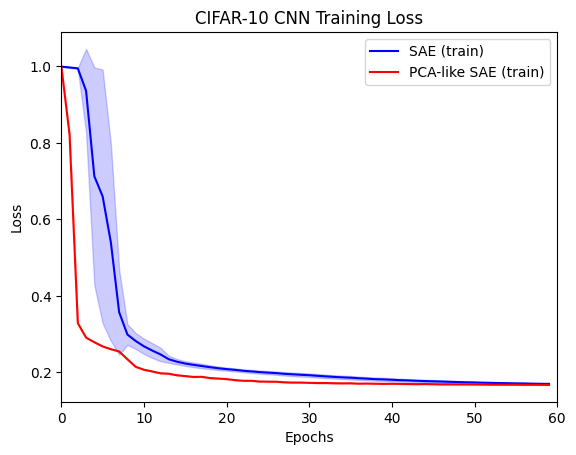

In [10]:
plt.plot(train_loss_mean, label='SAE (train)', color='blue')
plt.fill_between(np.arange(len(train_loss_mean)), train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
plt.plot(train_loss_mean_pca, label='PCA-like SAE (train)', color='red')
plt.fill_between(np.arange(len(train_loss_mean_pca)), train_loss_mean_pca - train_loss_std_pca, train_loss_mean_pca + train_loss_std_pca, alpha=0.2, color='red')
plt.legend()
plt.title('CIFAR-10 CNN Training Loss')
plt.xlabel('Epochs')
plt.xlim(0, 60)
plt.ylabel('Loss')
plt.show()

In [12]:
from rf_computation import compute_final_rfs

dae_rfs = compute_final_rfs(model_type='sae-latent-pca-init-new', dataset='cifar', size_ls=None, num_models=1, num_epochs=60, base_path=os.path.expanduser('~/'))

SAE-LATENT-PCA-INIT-NEW: 100%|██████████| 1/1 [00:27<00:00, 27.50s/it]


In [13]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [14]:
dae_rfs.shape

AttributeError: 'list' object has no attribute 'shape'

In [15]:
# dae_rfs = np.load('Results/cifar_sae-latent-pca-init_final_rfs.npy')
dae_rfs = np.repeat(dae_rfs, 10, axis=0)
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
print(dae_rfs.shape)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

(10, 60, 128, 3, 32, 32)


In [16]:
dae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [17]:
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [18]:
np.save('Results/cifar_sae_rfs.npy', sae_rfs)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

In [19]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=dae_rfs, num_models=10, epoch=0)

100%|██████████| 10/10 [00:00<00:00, 24.39it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_development_notebooks/paper_development_notebooks/Results/new/png/cifar_power_spectrum_individual.png'

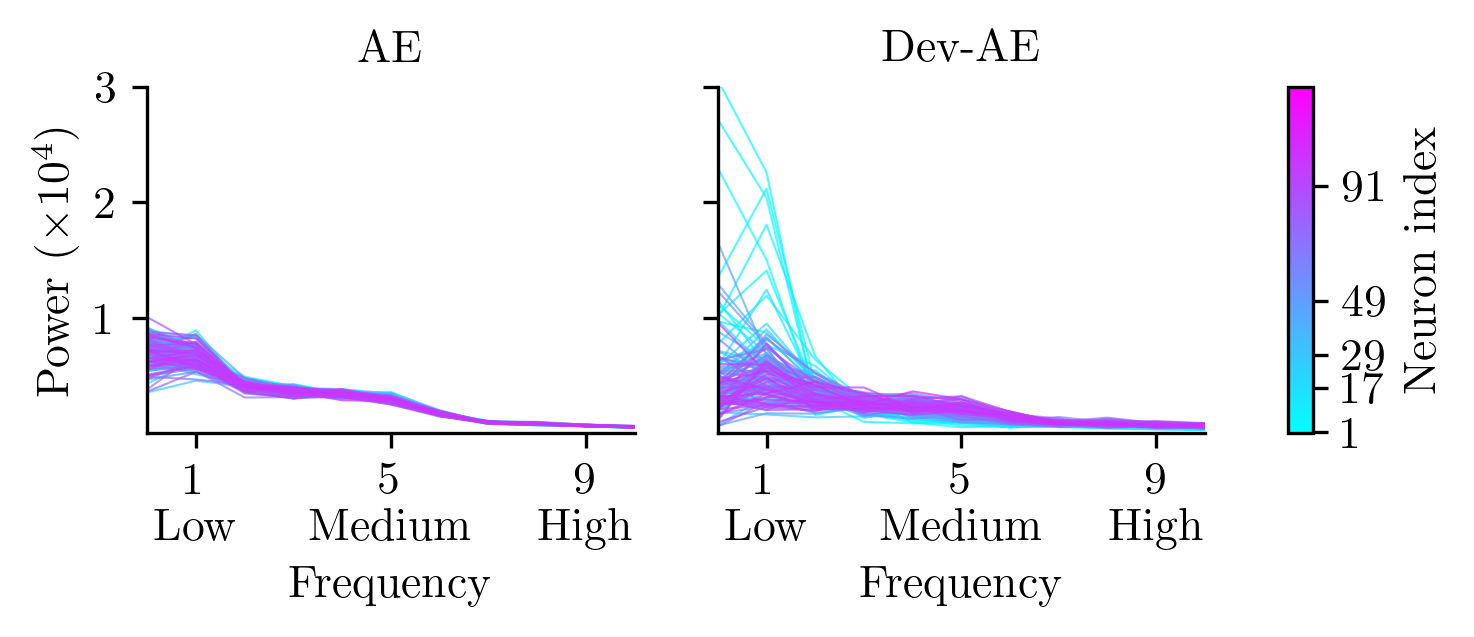

In [23]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cifar', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra, save_path='paper_development_notebooks/Results/new')

NameError: name 'fig' is not defined

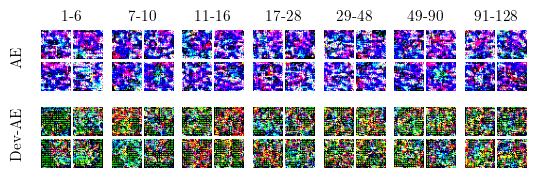

In [21]:
from plot_example_rfs import plot_example_rfs

fig = plt.figure(figsize=(6.26, 1.9))
ax = fig.add_subplot(111)
plot_example_rfs(ax, dataset='cifar', epoch_idx=59)
plt.close(fig)